This notebook runs **normative modeling** of **average structural connectivity** as a function of **age**. This enables the build of **normative charts of structural connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. A battery of models (statistical frameorks) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of structural connectivity. Inter- and intra- hemishpheric subsets of the structural connetivity are also investigated.


In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their SC matrices

In [2]:
cwd = os.getcwd()

In [3]:
sc_df = pd.read_json('SC_df.json')

In [4]:
sc_df.isna().sum()

ID_Visit     0
SubjectID    0
Age          1
Sex          0
SC           0
SClog10      0
dtype: int64

In [5]:
sc_df = sc_df.dropna()
sc_df['SC'] = sc_df['SC'].apply(np.array)
sc_df['SClog10'] = sc_df['SClog10'].apply(np.array)

In [6]:
sc_df['Mean_SC'] = sc_df['SC'].apply(np.mean)
sc_df['Mean_SClog10'] = sc_df['SClog10'].apply(np.mean)

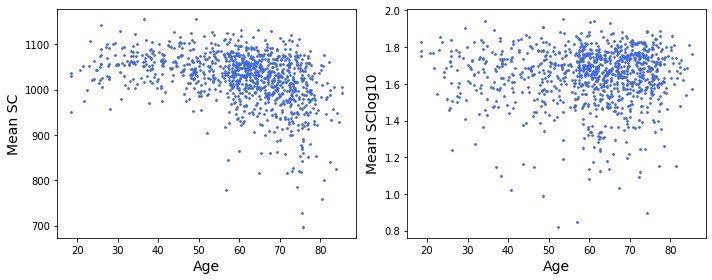

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True)
ax[0].scatter(sc_df['Age'], sc_df['Mean_SC'], s=3, color='royalblue') ; ax[0].set(ylabel='Mean SC')
ax[1].scatter(sc_df['Age'], sc_df['Mean_SClog10'], s=3, color='royalblue') ; ax[1].set(ylabel='Mean SClog10')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.tight_layout()
plt.show()

# 1. Modeling normative charts of average SC through Aging

We will perform hierarchical bayesian regression of the response "Mean_SC" (subject-specific) on the predictor or covariate "Age".

In [8]:
x_str = 'Age' ; y_str = 'Mean_SC'

In [9]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

## 1.1 Linear models

Linear models assume linear effects on covariates ($x$), of the form $\beta_0 + \beta_1 x$. Classical linear regression models observation $y$ as $y = \beta_0 + \beta_1 x + \zeta$ where $\zeta$ is the residual error. Typically, it is assumed that errors are normally distributed, that is: $ \zeta \sim N(0, \sigma)$. The latter makes the regression equivalent to $y \sim N(\beta_0 + \beta_1 x, \sigma)$ which means we assume the response $y$ to be normally distributed around a linear function of the covariate, with a certain dispertion or standard deviation $\sigma$. 

The value of $\sigma$ (to be estimated) can either be assumed to not depend on the covariate values, in this case we say we model with homoscedastic noise, and will estimate only a single value for this parameter. If we assume that the noise varies along with the covariate, for example when we see that the data is more dispersed for some values of the covariate, and more concentrated for others, we say that we assume heteroscedastic noise. Hence, we can put linear effects on the noise parameter, $\sigma \sim N(\alpha_0 + \alpha_1 x, \eta)$.


Linear effects can also be assumed on parameters of higher-order, such as the ones in SHASH (SinH-ArcSinH) distribution. SHASH is a generalization of the normal distribution. While the normal distribution is symmetric and has light to moderate tails and can be defined by just two parameters (location (mean) and scale or (standard deviation)), the SHASH distribution has two more parameters which control asymmetry and tail weight. See (https://statisticaloddsandends.wordpress.com/2019/04/15/the-sinh-arcsinh-normal-distribution/).
In the PCNtoolkit architecture, the asymetry parameter is denoted $\epsilon$ and the tail weight is $\delta$. When $\epsilon=0$ and $\delta=1$, it is equivalent to the normal distribution.

Here we will try to fit the data with different models, assuming always linear effects on the mean, but trying without and with linear effects on the other parameters $\sigma$, $\epsilon$ and $\delta$.

We will try the following models:

* "lin_hom" : $y \sim N(\mu,\sigma), \mu = \beta x$,
* "lin_het": $y \sim N(\mu,\sigma), \mu = \beta_{1}x, \sigma = \beta_{2}x$
* "lin_shash_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x$ 
* "lin_shash_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$
* "lin_shash_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$
* "lin_shash_all" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$

Note that pcntoolkit assumes by default linear effects on the mean but not on the other parameter(s), and Normal distribution for the likelihood.

In [10]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               }, 
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
There were 319 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

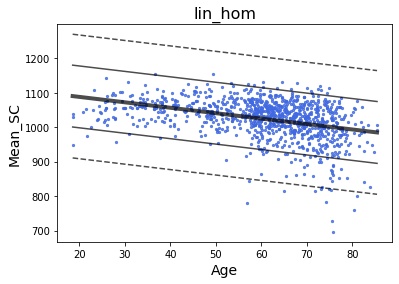

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [y_like]


Output()

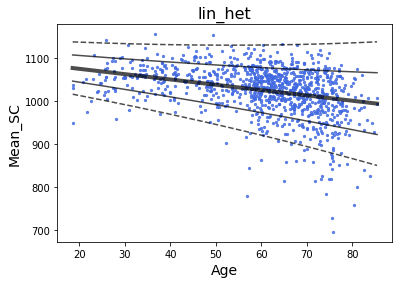

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
Sampling: [y_like]


Output()

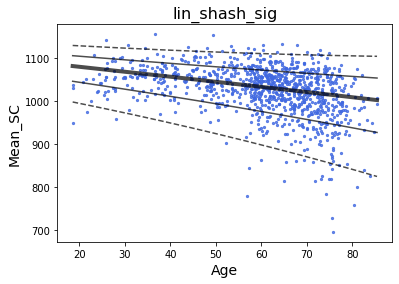

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
Sampling: [y_like]


Output()

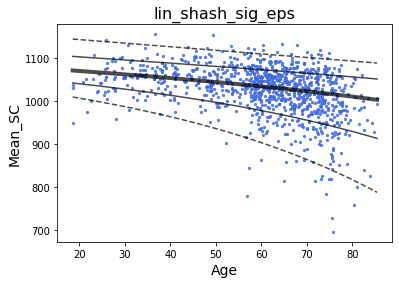

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
Sampling: [y_like]


Output()

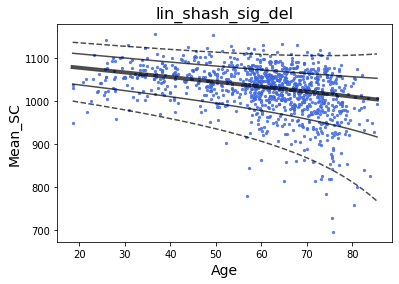

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
Sampling: [y_like]


Output()

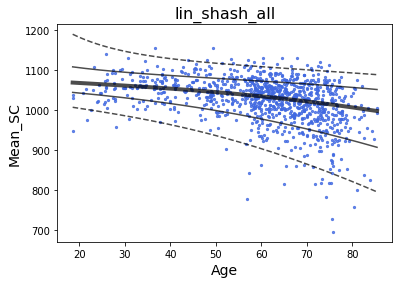

In [11]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Note that the linear regression with no variation of the noise (lin_hom) raises numerous divergences in HMC sampling, which indicates this model is not adapted to the data at hand.

## 1.2 Non-linear (b-splines) models

Now, instead of assuming linear effects on model parameters, we will assume a more complex relashionship linking the covariate to the observations. Instead of the linear relashionship of the form $\beta_0 + \beta_1 x$, we will assume a non-linear function of the covariate $f(x)$, in the form of a B-spline (https://en.wikipedia.org/wiki/B-spline). For doing this, we pass as an argument model_type='bspline'. This type of models are called Generalized Additive Models (GAM). When GAM are used with higher order (shape) parameters, they are called GAMLSS [1].

Again, we will try the following models:

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$
             
          
             
[1] R. A. Rigby, D. M. Stasinopoulos, Generalized Additive Models for Location, Scale and Shape, Journal of the Royal Statistical Society Series C: Applied Statistics, Volume 54, Issue 3, June 2005, Pages 507–554, https://doi.org/10.1111/j.1467-9876.2005.00510.x

In [12]:
models_name = ['gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

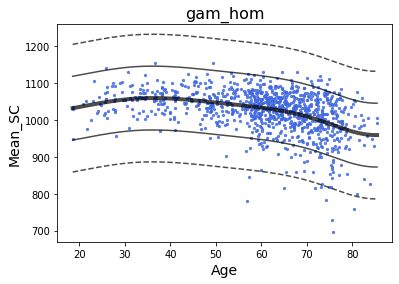

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.
Sampling: [y_like]


Output()

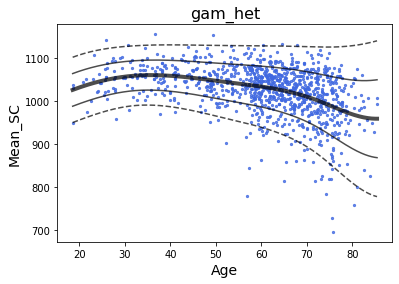

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 105 seconds.
Sampling: [y_like]


Output()

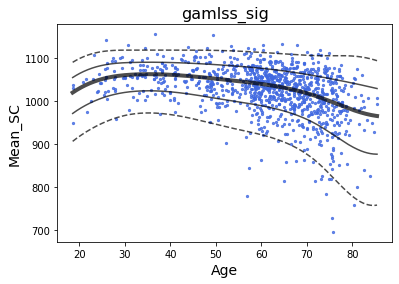

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 111 seconds.
Sampling: [y_like]


Output()

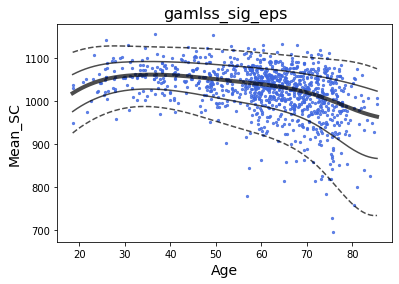

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 116 seconds.
Sampling: [y_like]


Output()

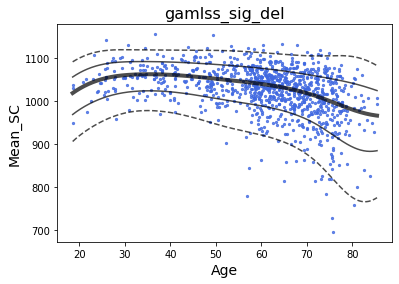

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 127 seconds.
Sampling: [y_like]


Output()

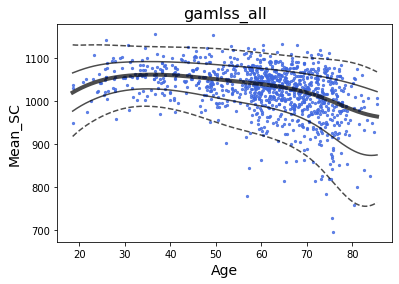

In [13]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Again, the model with homoscedastic noise raises numerous divergences. Indeed, one can directly see from the data that the dispersion of the observations is not the same accross the age. 

### How to load models if necessary

In [46]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all',
               'gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
 
x_str = 'Age' ; y_str = 'Mean_SC'
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

for name in models_name :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    models_dict['name'].append(name)
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

## 1.3 Model comparison

The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of structural connectivity.
The model comparison will be based on the estimated log predictive density (elpd) of the models. For that, we need the pointwise log likelihood, that is the log likelihood at each data point.

In [47]:
for i in range(len(models_dict['name'])) :
    nm, inscaler = models_dict['object'][i], models_dict['inscaler'][i]
    #way i found to sample from posterior predictive
    #nm.hbr.idata object is actualized
    nm.get_mcmc_quantiles(inscaler.fit_transform(sc_df[x_str]))

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

In [48]:
models_dict['loglik'] = []
for i in range(len(models_dict['name'])) :
    nm, outscaler = models_dict['object'][i], models_dict['outscaler'][i]
    samples = nm.hbr.idata.posterior_predictive
    loglik = compute_loglikelihood(nm, samples, outscaler.fit_transform(sc_df[y_str]))
    models_dict['loglik'].append(loglik)

/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)


In [49]:
sum_loglik = []
for l in models_dict['loglik'] :
    sum_loglik.append(np.nanmean(l, axis=(0, 1)).sum())
sum_loglik 

[-inf,
 -1342.4102090551341,
 -1317.4808978556548,
 -1300.5090196331055,
 -1311.5010202345895,
 -1304.252543257588,
 -inf,
 -1299.473985797198,
 -1287.3252731139612,
 -1277.4619882742318,
 -1284.1111582604512,
 -1275.6565147480385]

For the models with homoscedastic noise, the likelihood is so low in some datapoints that it raises the log likelihood to -infinity. Indeed, these models are disqualified from the comparison, as they are clearly not adapted, because they cannot take into  account the heterogeneous distribution of noise with respect to age.

In [50]:
nm_idata_list = []
for i in range(len(models_dict['object'])) :
    nm_idata_list.append(models_dict['object'][i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": models_dict['loglik'][i]})

In [51]:
models_data_dict = {m: d for m, d in zip(models_dict['name'], nm_idata_list)}
compare = az.compare(models_data_dict)
compare

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a mo

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gamlss_sig_eps,0,-1295.821442,34.348690,0.000000,0.083333,37.086097,0.000000,False,log
gamlss_all,1,-1299.968621,45.384652,4.147179,0.083333,36.307672,2.358522,True,log
gamlss_sig,2,-1303.713037,31.034730,7.891594,0.083333,38.201785,4.576012,True,log
gamlss_sig_del,3,-1305.325304,40.061642,9.503862,0.083333,37.072926,4.555005,True,log
gam_het,4,-1306.031662,12.428515,10.210219,0.083333,33.730126,14.567217,False,log
lin_shash_sig_eps,5,-1310.787820,19.839688,14.966377,0.083333,37.053156,12.075633,False,log
lin_shash_all,6,-1322.243760,35.981203,26.422318,0.083333,36.963289,13.604484,True,log
lin_shash_sig_del,7,-1323.031308,21.990813,27.209866,0.083333,35.795015,11.443433,False,log
lin_shash_sig,8,-1326.288299,17.207920,30.466857,0.083333,38.129483,11.769984,False,log
lin_het,9,-1345.857306,6.692702,50.035864,0.083333,33.634368,19.073635,False,log


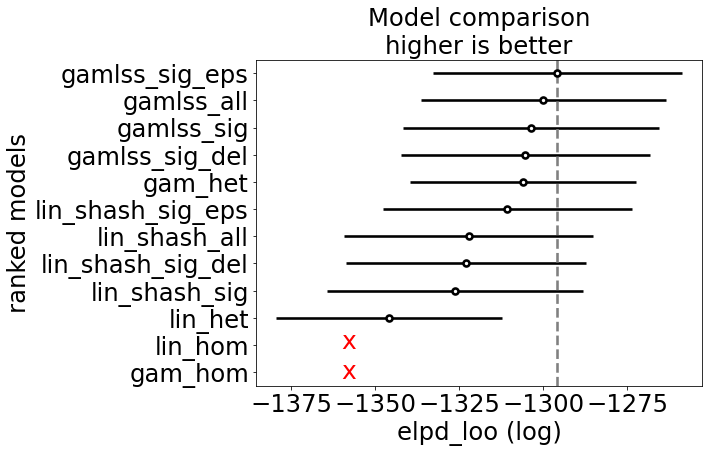

In [52]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 
ax.text(-1360, -1.02, s='x', size=25, color='red')
ax.text(-1360, -0.92, s='x', size=25, color='red');

Model comparison is to be interpeted with caution, as multiple warnings have been raised during computation, indicating that the findings might not be reliable. Furthermore, error bars on the graph above are quite overlapping with one another, indicating that models have comparable predictive power.

## 1.4 Summary

Finally, we plot the normative charts (quantiles of the estimated normative models) of average SC values with respect to age, for all the models we have tried. We indicate their rank based on model comparison, keeping in mind that only the models with homoscedastic noise are "bad" models.

In [53]:
subtitles = [r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta x$',
             r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f(x)$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$']

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Text(1, 0.2, 'Non-linear')

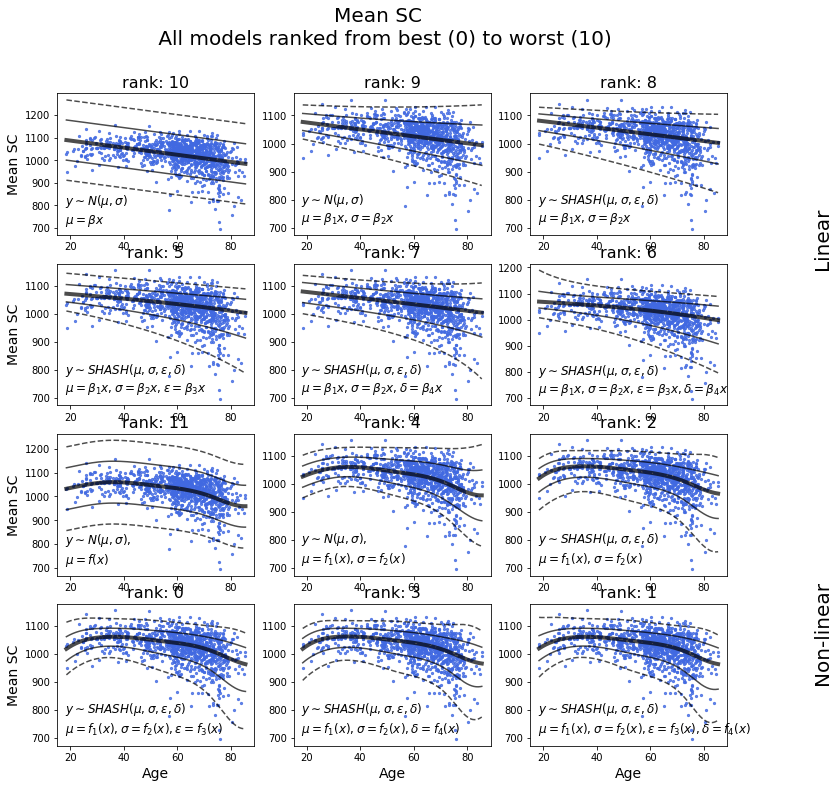

In [66]:
fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(12, 12))
    
for i in range(len(models_dict['name'])) :
    plot_quantiles(models_dict['object'][i], 
                   sc_df, 
                   x_str, 
                   y_str, 
                   models_dict['inscaler'][i], 
                   models_dict['outscaler'][i], 
                   n_qs=2,
                   ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title('rank: ' + str(compare['rank'][models_dict['name']][i]), size=16)
    ax[i//3, i%3].set_xlabel('')
    ax[i//3, i%3].set_ylabel('')
    if i%3 == 0 :
        ax[i//3, i%3].set_ylabel('Mean SC')
    if i//3 == 3 :
        ax[i//3, i%3].set_xlabel('Age')
    ax[i//3, i%3].text(18, 720, s=subtitles[i], size=12)

fig.suptitle('Mean SC \n All models ranked from best (0) to worst (10)', size=20)
fig.text(1, 0.68, 'Linear', rotation=90, size=20)
fig.text(1, 0.2, 'Non-linear', rotation=90, size=20)

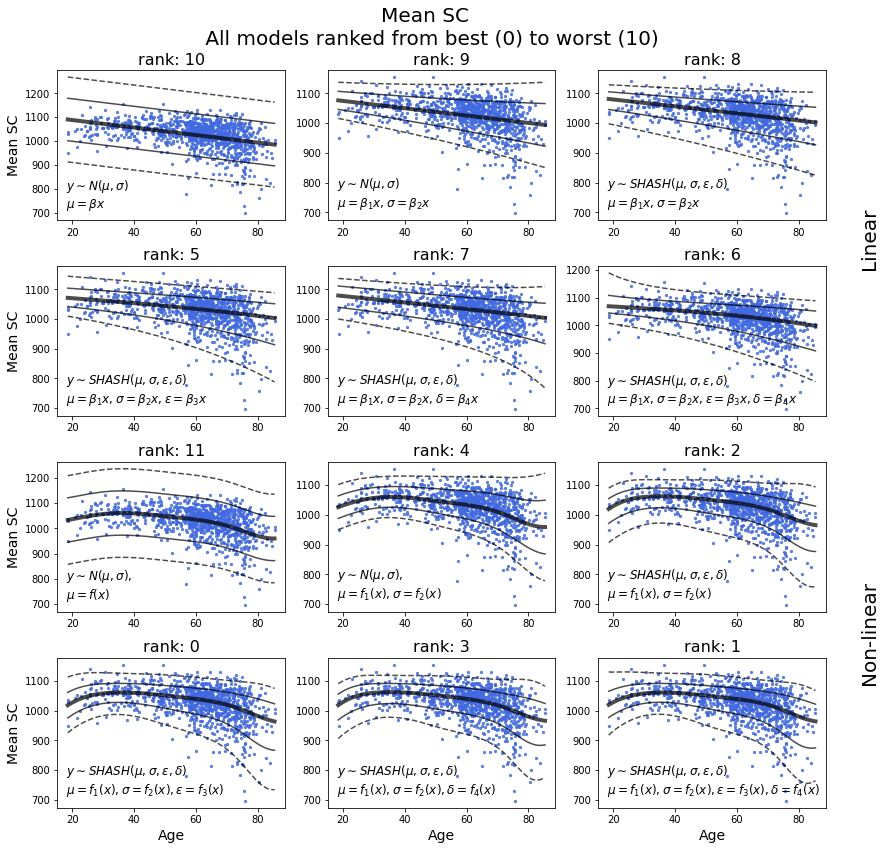

In [67]:
fig.tight_layout()
fig

# 2. & 3. SC inter-hemisheric and intra-hemispheric

Now, we will separate SC values in two: the inter-hemispheric connectivity and the intra-hemispheric connectivity. We will repeat the exact same process presented above, for each of these two subsets.

In [8]:
n_nodes = sc_df['SC'][0].shape[0]
Mask = np.zeros((n_nodes, n_nodes), dtype='int')
inter_ = np.array(list(product(np.arange(0, n_nodes//2), np.arange(n_nodes//2, n_nodes))))
Mask[inter_[:, 0], inter_[:, 1]] = 1
Mask[inter_[:, 1], inter_[:, 0]] = 1
inter_i = np.where(Mask == 1)
intra_i = np.where(Mask == 0)
sc_df['Mean_inter_SC'] = sc_df['SC'].apply(lambda x: np.mean(x[inter_i]))
sc_df['Mean_intra_SC'] = sc_df['SC'].apply(lambda x: np.mean(x[intra_i]))

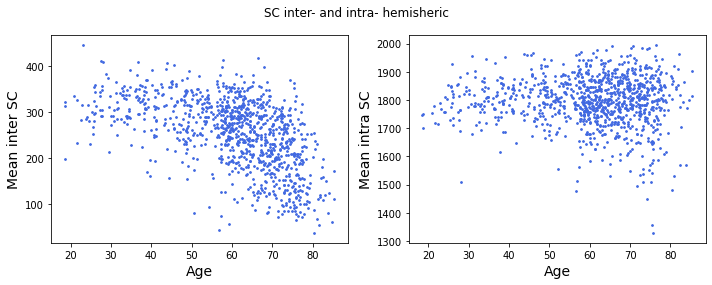

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True)
ax[0].scatter(sc_df['Age'], sc_df['Mean_inter_SC'], s=3, color='royalblue') ; ax[0].set(ylabel='Mean inter SC')
ax[1].scatter(sc_df['Age'], sc_df['Mean_intra_SC'], s=3, color='royalblue') ; ax[1].set(ylabel='Mean intra SC')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.suptitle('SC inter- and intra- hemisheric')
fig.tight_layout()
plt.show()

# 2. Modeling normative charts of average Inter-Hemispheric SC through Aging

In [27]:
x_str = 'Age' ; y_str = 'Mean_inter_SC'

In [28]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

## 2.1. Linear models

* "lin_hom" : $y \sim N(\mu,\sigma), \mu = \beta x$,
* "lin_het": $y \sim N(\mu,\sigma), \mu = \beta_{1}x, \sigma = \beta_{2}x$
* "lin_shash_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x$ 
* "lin_shash_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$
* "lin_shash_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$
* "lin_shash_all" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$

In [29]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               }, 
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 304 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

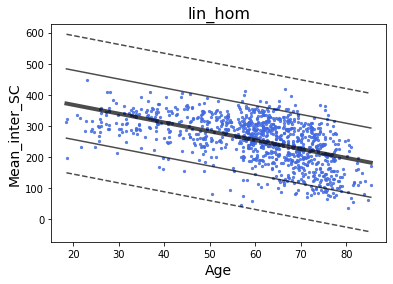

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [y_like]


Output()

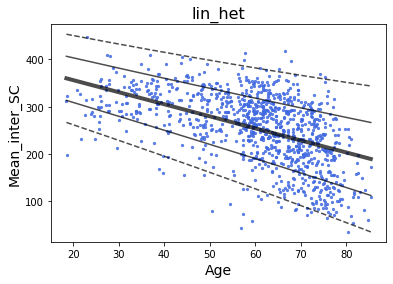

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
Sampling: [y_like]


Output()

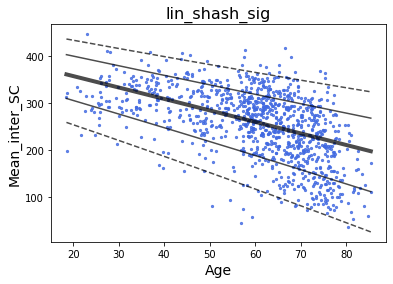

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.
Sampling: [y_like]


Output()

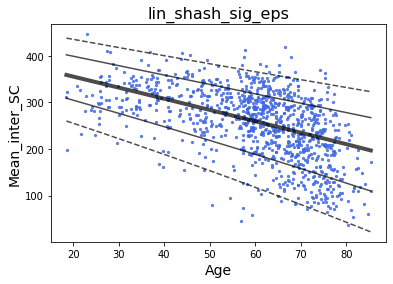

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.
Sampling: [y_like]


Output()

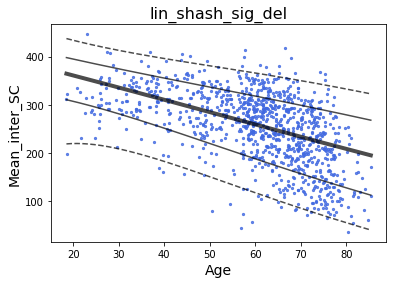

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.
Sampling: [y_like]


Output()

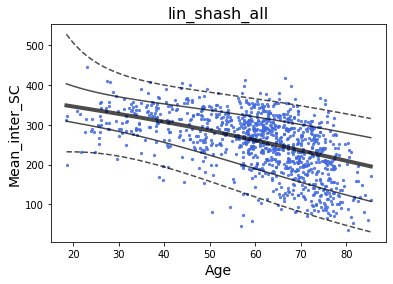

In [30]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Again, note the divergences for the first model.

## 2.2 Non-linear (b-splines) models

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$
             
          

In [31]:
models_name = ['gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
There were 25 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

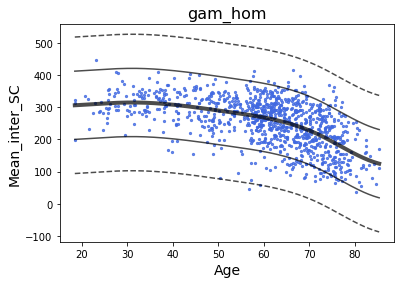

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
Sampling: [y_like]


Output()

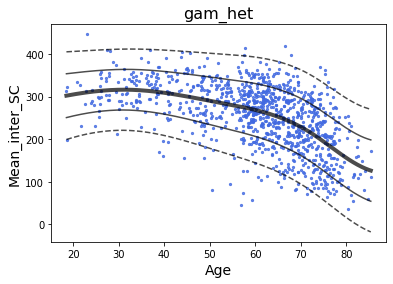

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 102 seconds.
Sampling: [y_like]


Output()

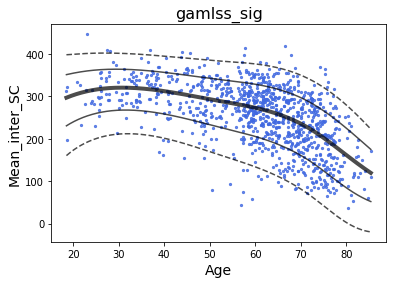

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 112 seconds.
Sampling: [y_like]


Output()

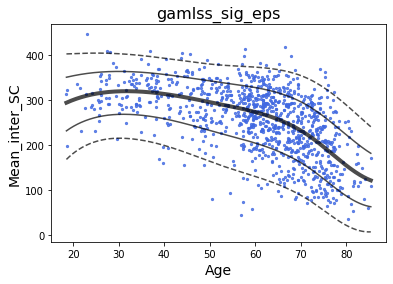

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 118 seconds.
Sampling: [y_like]


Output()

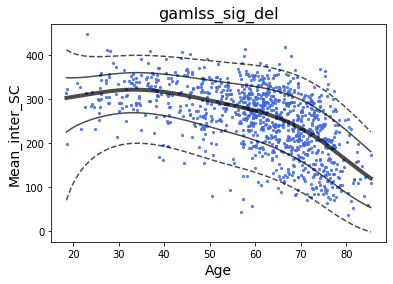

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 125 seconds.
Sampling: [y_like]


Output()

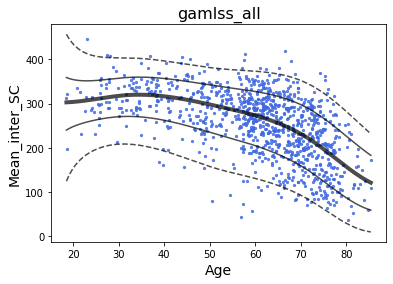

In [32]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Again, divergences for the first model.

### How to load models if necesssary

In [68]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all',
               'gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
 
x_str = 'Age' ; y_str = 'Mean_inter_SC'
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

for name in models_name :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    models_dict['name'].append(name)
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

## 2.3 Model comparison

In [69]:
for i in range(len(models_dict['name'])) :
    nm, inscaler = models_dict['object'][i], models_dict['inscaler'][i]
    #way i found to sample from posterior predictive
    #nm.hbr.idata object is actualized
    nm.get_mcmc_quantiles(inscaler.fit_transform(sc_df[x_str]))

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

In [70]:
models_dict['loglik'] = []
for i in range(len(models_dict['name'])) :
    nm, outscaler = models_dict['object'][i], models_dict['outscaler'][i]
    samples = nm.hbr.idata.posterior_predictive
    loglik = compute_loglikelihood(nm, samples, outscaler.fit_transform(sc_df[y_str]))
    models_dict['loglik'].append(loglik)

/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)


In [71]:
sum_loglik = []
for l in models_dict['loglik'] :
    sum_loglik.append(np.nanmean(l, axis=(0, 1)).sum())
sum_loglik 

[-inf,
 -1282.8813349191778,
 -1295.762782691162,
 -1293.128791020385,
 -1309.5519054087724,
 -1329.4981014101788,
 -inf,
 -1242.2675450401211,
 -1235.2533650650894,
 -1227.888983857139,
 -1263.819960766623,
 -1257.456213084928]

In [72]:
nm_idata_list = []
for i in range(len(models_dict['object'])) :
    nm_idata_list.append(models_dict['object'][i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": models_dict['loglik'][i]})

In [73]:
models_data_dict = {m: d for m, d in zip(models_dict['name'], nm_idata_list)}
compare = az.compare(models_data_dict)
compare

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/pytho

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gamlss_sig_eps,0,-1239.091359,20.850467,0.000000,0.083333,21.566637,0.000000,True,log
gamlss_sig,1,-1246.626427,21.459906,7.535068,0.083333,22.311527,2.374571,True,log
gam_het,2,-1247.708983,10.241520,8.617624,0.083333,24.474839,6.311675,False,log
gamlss_all,3,-1277.057254,35.461081,37.965896,0.083333,24.299016,8.247797,True,log
gamlss_sig_del,4,-1281.462603,32.920398,42.371245,0.083333,25.173447,8.752973,True,log
lin_het,5,-1285.028928,4.204332,45.937569,0.083333,22.321719,10.591091,False,log
lin_shash_sig_eps,6,-1299.689628,12.773144,60.598270,0.083333,16.627156,9.532765,False,log
lin_shash_sig,7,-1301.882004,11.966517,62.790645,0.083333,16.142887,9.559793,False,log
lin_shash_sig_del,8,-1319.161307,18.863546,80.069949,0.083333,18.820328,10.051606,False,log
lin_shash_all,9,-1339.363870,18.980846,100.272511,0.083333,20.704651,12.500604,False,log


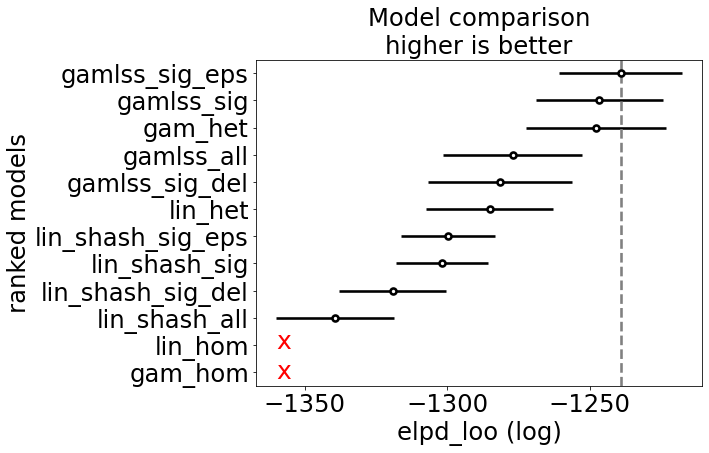

In [74]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 
ax.text(-1360, -1.02, s='x', size=25, color='red')
ax.text(-1360, -0.92, s='x', size=25, color='red');

Once again, we must point out that model comparison raises several warning and must be taken with caution. That having been said, a group of 3 models have seem to emerge as best candidates for trade-off between predtictive powr and complexity: GAMLSS with heteroscedastic noise and asymetry, GAMLSS with heteroscedastic noise only, and GAM with heteroscedastic noise. Again, models with homoscedastic noise must be discarded.

## 2.4 Summary

In [75]:
subtitles = [r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta x$',
             r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f(x)$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$']

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Text(1, 0.2, 'Non-linear')

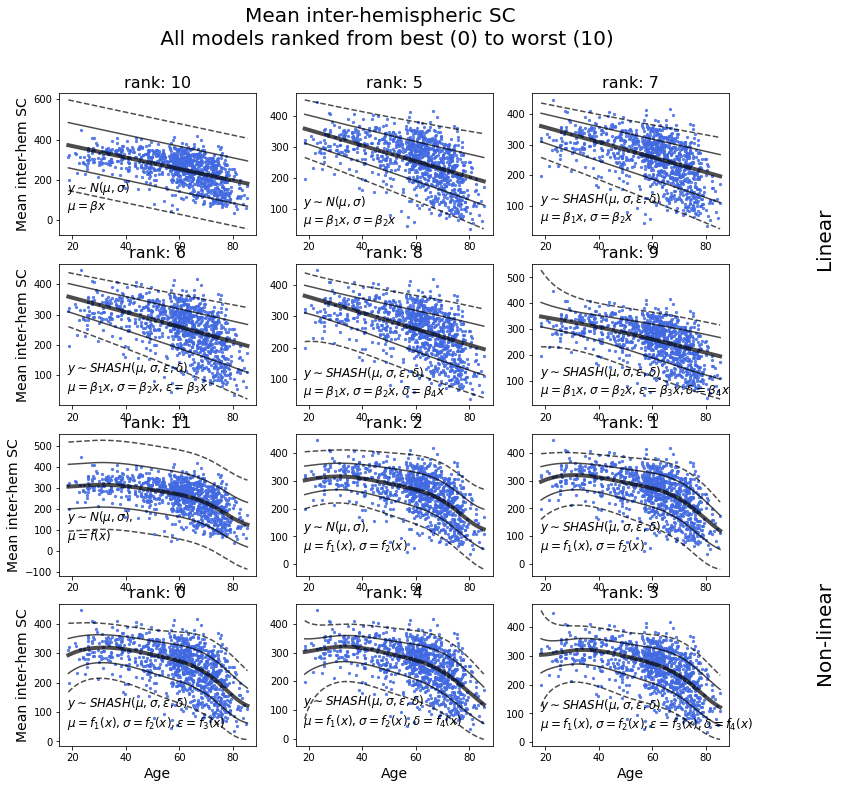

In [76]:
fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(12, 12))
    
for i in range(len(models_dict['name'])) :
    plot_quantiles(models_dict['object'][i], 
                   sc_df, 
                   x_str, 
                   y_str, 
                   models_dict['inscaler'][i], 
                   models_dict['outscaler'][i], 
                   n_qs=2,
                   ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title('rank: ' + str(compare['rank'][models_dict['name']][i]))
    ax[i//3, i%3].set_xlabel('')
    ax[i//3, i%3].set_ylabel('')
    if i%3 == 0 :
        ax[i//3, i%3].set_ylabel('Mean inter-hem SC')
    if i//3 == 3 :
        ax[i//3, i%3].set_xlabel('Age')
    ax[i//3, i%3].text(18, 50, s=subtitles[i], size=12)

fig.suptitle('Mean inter-hemispheric SC \n All models ranked from best (0) to worst (10)', size=20)
fig.text(1, 0.68, 'Linear', rotation=90, size=20)
fig.text(1, 0.2, 'Non-linear', rotation=90, size=20)

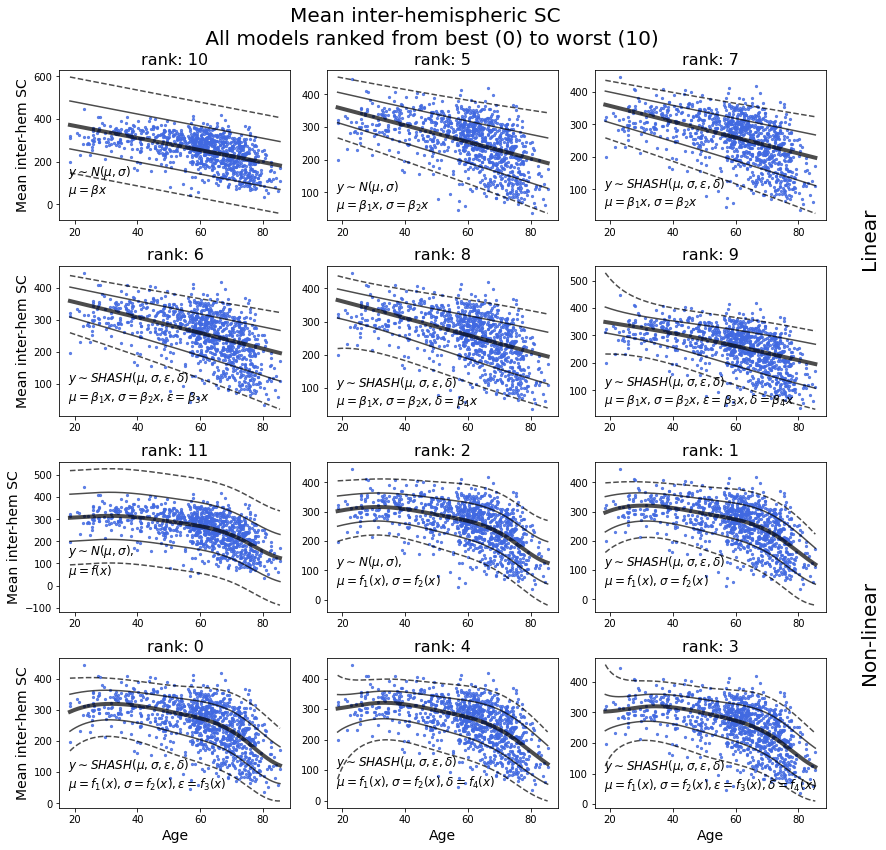

In [77]:
fig.tight_layout()
fig

# 3. Modeling normative charts of average Intra-Hemispheric SC through Aging

In [45]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

In [46]:
x_str = 'Age' ; y_str = 'Mean_intra_SC'

## 3.1 Linear models

* "lin_hom" : $y \sim N(\mu,\sigma), \mu = \beta x$,
* "lin_het": $y \sim N(\mu,\sigma), \mu = \beta_{1}x, \sigma = \beta_{2}x$
* "lin_shash_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x$ 
* "lin_shash_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$
* "lin_shash_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$
* "lin_shash_all" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$

In [47]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               }, 
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 290 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

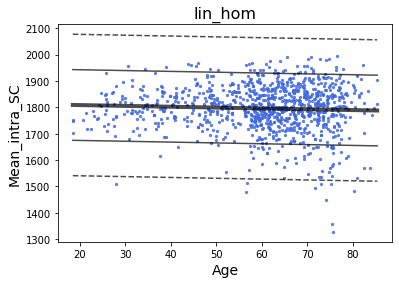

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [y_like]


Output()

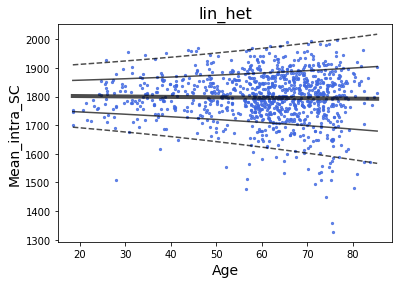

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
Sampling: [y_like]


Output()

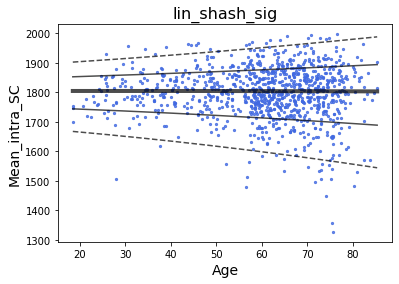

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
Sampling: [y_like]


Output()

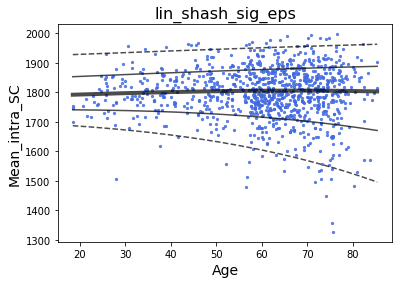

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.
Sampling: [y_like]


Output()

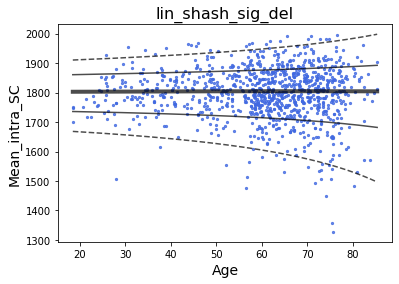

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Sampling: [y_like]


Output()

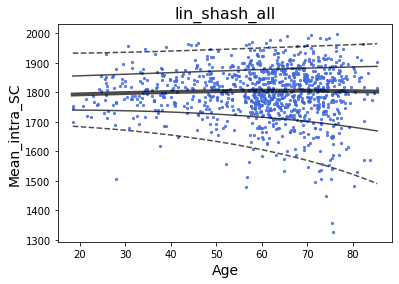

In [48]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Here also, we see divergences with the homoscedastic noise model.

## 3.2 Non-linear (b-splines) models

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$
             
          

In [49]:
models_name = ['gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.
There were 42 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

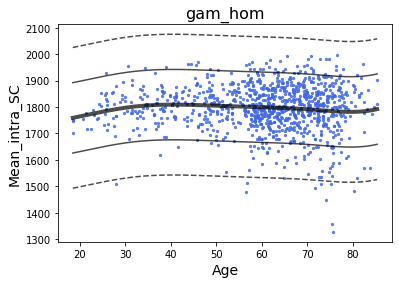

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
Sampling: [y_like]


Output()

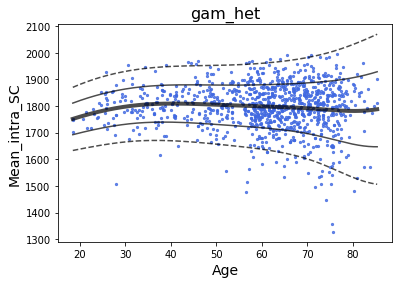

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 86 seconds.
Sampling: [y_like]


Output()

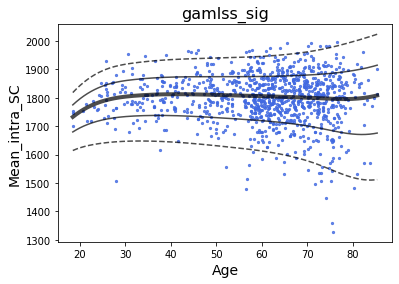

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 96 seconds.
Sampling: [y_like]


Output()

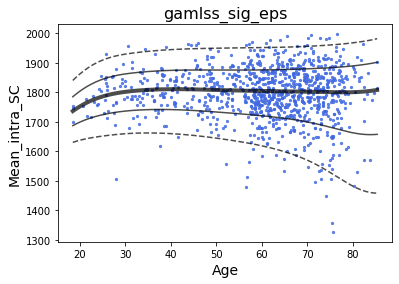

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 109 seconds.
Sampling: [y_like]


Output()

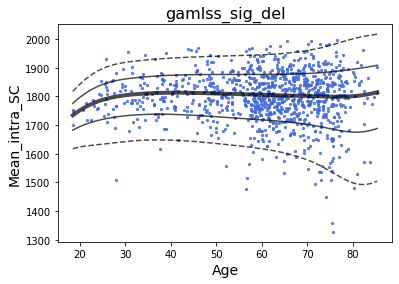

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 117 seconds.
Sampling: [y_like]


Output()

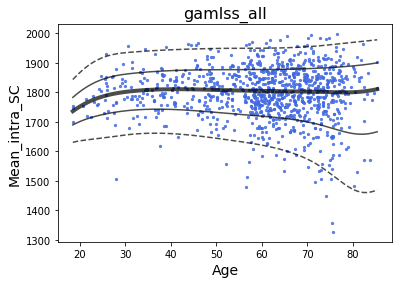

In [50]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(sc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, sc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Divergences when homoscediastic noise again

### How to load models if necesssary

In [78]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all',
               'gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
 
x_str = 'Age' ; y_str = 'Mean_intra_SC'
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

for name in models_name :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    models_dict['name'].append(name)
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

## 3.3 Model comparison

In [79]:
for i in range(len(models_dict['name'])) :
    nm, inscaler = models_dict['object'][i], models_dict['inscaler'][i]
    #way i found to sample from posterior predictive
    #nm.hbr.idata object is actualized
    nm.get_mcmc_quantiles(inscaler.fit_transform(sc_df[x_str]))

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

In [80]:
models_dict['loglik'] = []
for i in range(len(models_dict['name'])) :
    nm, outscaler = models_dict['object'][i], models_dict['outscaler'][i]
    samples = nm.hbr.idata.posterior_predictive
    loglik = compute_loglikelihood(nm, samples, outscaler.fit_transform(sc_df[y_str]))
    models_dict['loglik'].append(loglik)

/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)


In [81]:
sum_loglik = []
for l in models_dict['loglik'] :
    sum_loglik.append(np.nanmean(l, axis=(0, 1)).sum())
sum_loglik 

[-inf,
 -1427.9272234452271,
 -1430.484719304479,
 -1420.558251698856,
 -1429.006665942798,
 -1420.3465218116364,
 -inf,
 -1419.3253937336156,
 -1419.46895477448,
 -1414.9164010109698,
 -1416.3841666688877,
 -1411.556187127066]

In [82]:
nm_idata_list = []
for i in range(len(models_dict['object'])) :
    nm_idata_list.append(models_dict['object'][i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": models_dict['loglik'][i]})

In [83]:
models_data_dict = {m: d for m, d in zip(models_dict['name'], nm_idata_list)}
compare = az.compare(models_data_dict)
compare

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1038: RuntimeWarning: overflow encountered in divide
  b_ary /= prior_bs * ary[int(n / 4 + 0.5) - 1]
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1042: RuntimeWarning: invalid value encountered in divide
  len_scale = n * (np.log(-(b_ary / k_ary)) - k_ary - 1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1058: RuntimeWarning: invalid value encountered in scalar divide
  sigma = -k_post / b_post
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one o

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gam_het,0,-1425.628625,11.878309,0.000000,0.083333,29.479550,0.000000,False,log
lin_het,1,-1431.186992,6.277955,5.558367,0.083333,30.435623,5.308131,False,log
lin_shash_sig_eps,2,-1431.331510,20.307791,5.702885,0.083333,35.706335,11.818777,True,log
gamlss_sig_eps,3,-1432.828598,33.085084,7.199973,0.083333,34.948993,10.481850,True,log
gamlss_sig,4,-1434.332378,28.538540,8.703753,0.083333,34.109616,10.403882,False,log
lin_shash_all,5,-1435.610754,29.464100,9.982129,0.083333,35.182735,11.396563,True,log
gamlss_all,6,-1435.811540,44.621103,10.182915,0.083333,33.953081,9.989866,True,log
gamlss_sig_del,7,-1435.813596,37.250287,10.184971,0.083333,33.298402,10.515905,True,log
lin_shash_sig,8,-1439.039195,16.805123,13.410570,0.083333,35.186771,12.222904,False,log
lin_shash_sig_del,9,-1440.480394,22.356339,14.851770,0.083333,33.820238,11.931565,False,log


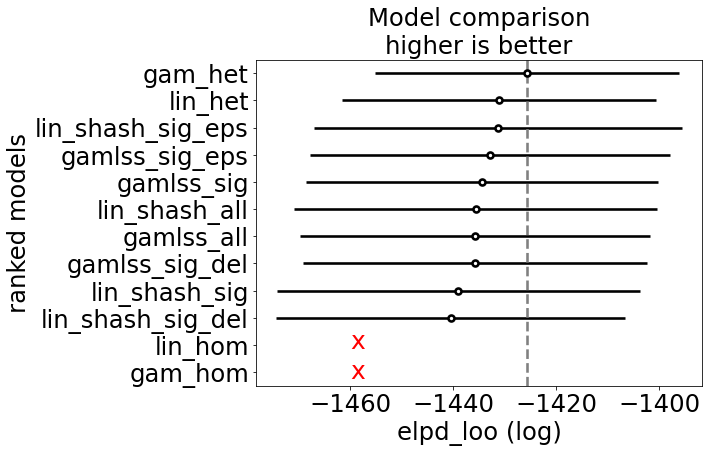

In [84]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 
ax.text(-1460, -1.02, s='x', size=25, color='red')
ax.text(-1460, -0.92, s='x', size=25, color='red');

This time again, model comparison is to be taken with caution. In addition, widespread errorbars with major overlap may indicate that all models are pretty similar, excepted the two badly performing ones.

## 3.4 Summary

In [85]:
subtitles = [r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta x$',
             r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f(x)$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$']

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Text(1, 0.2, 'Non-linear')

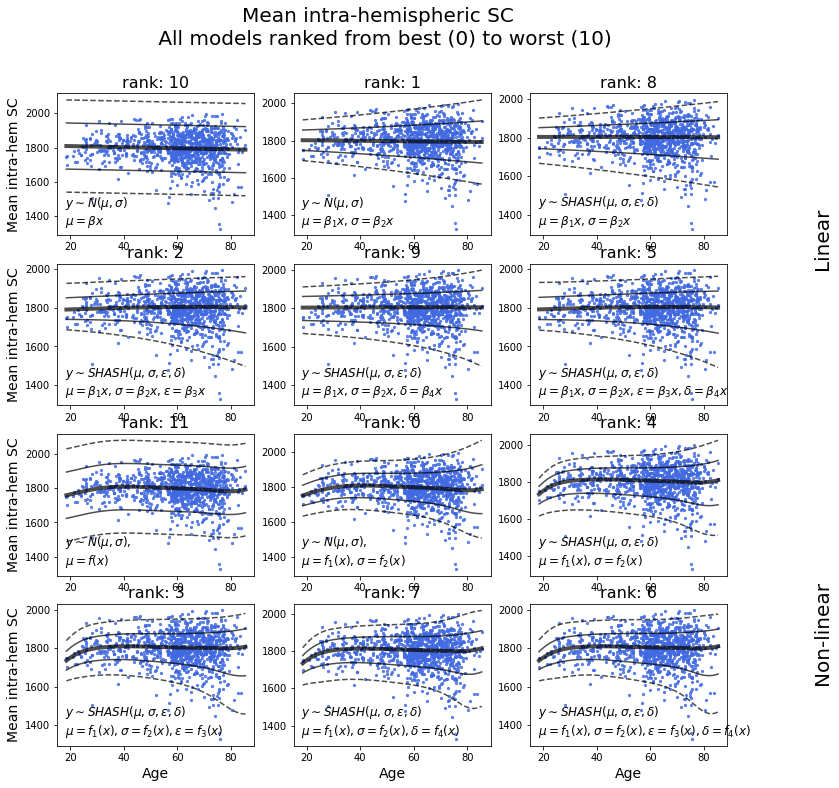

In [86]:
fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(12, 12))
    
for i in range(len(models_dict['name'])) :
    plot_quantiles(models_dict['object'][i], 
                   sc_df, 
                   x_str, 
                   y_str, 
                   models_dict['inscaler'][i], 
                   models_dict['outscaler'][i], 
                   n_qs=2,
                   ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title('rank: ' + str(compare['rank'][models_dict['name']][i]))
    ax[i//3, i%3].set_xlabel('')
    ax[i//3, i%3].set_ylabel('')
    if i%3 == 0 :
        ax[i//3, i%3].set_ylabel('Mean intra-hem SC')
    if i//3 == 3 :
        ax[i//3, i%3].set_xlabel('Age')
    ax[i//3, i%3].text(18, 1350, s=subtitles[i], size=12)

fig.suptitle('Mean intra-hemispheric SC \n All models ranked from best (0) to worst (10)', size=20)
fig.text(1, 0.68, 'Linear', rotation=90, size=20)
fig.text(1, 0.2, 'Non-linear', rotation=90, size=20)

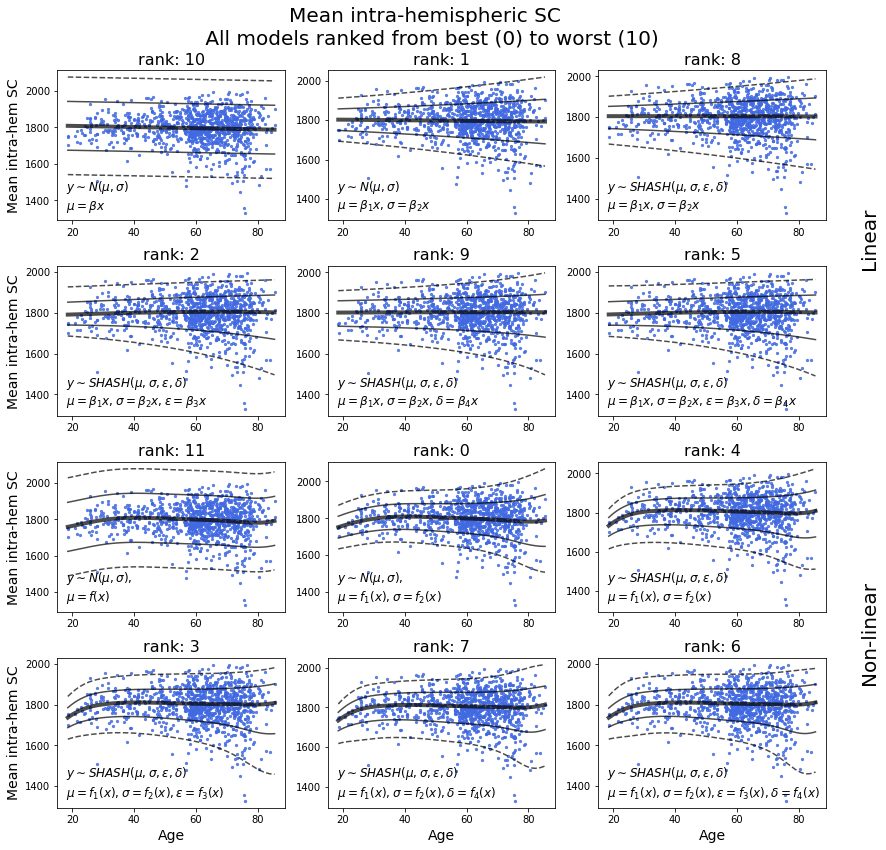

In [87]:
fig.tight_layout()
fig

# 5. Final summary: best fits

We show the "best fits" (according to model comparison) of normative models (with quantiles) for average SC, and average inter- and intra- hemispheric SC subsets.

The normative charts, learned from the data under guidance of a model, embrace both aleatoric uncertainty (inherent variability) and epistemic uncertainty (for example, lack of data).

In [10]:
with open("./reg_fits/x=Age_y=Mean_SC_fit_gamlss_sig_eps.pkl",'rb') as file :
    reg_Age_mean_SC = pickle.load(file)
    
with open("./reg_fits/x=Age_y=Mean_inter_SC_fit_gamlss_sig_eps.pkl",'rb') as file :
    reg_Age_mean_inter_SC = pickle.load(file)
    
with open("./reg_fits/x=Age_y=Mean_intra_SC_fit_gam_het.pkl",'rb') as file :
    reg_Age_mean_intra_SC = pickle.load(file)

In [11]:
inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

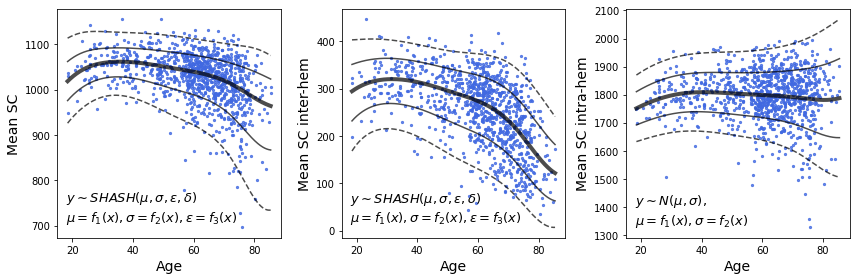

In [45]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
plot_quantiles(reg_Age_mean_SC, sc_df, 'Age', 'Mean_SC', inscaler, outscaler, n_qs=2, ax=ax[0])
plot_quantiles(reg_Age_mean_inter_SC, sc_df, 'Age', 'Mean_inter_SC', inscaler, outscaler, n_qs=2, ax=ax[1])
plot_quantiles(reg_Age_mean_intra_SC, sc_df, 'Age', 'Mean_intra_SC', inscaler, outscaler, n_qs=2, ax=ax[2])
ax[0].set(ylabel='Mean SC')
ax[1].set(ylabel='Mean SC inter-hem')
ax[2].set(ylabel='Mean SC intra-hem')

ax[0].text(18, 
           710, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
          size=13)

ax[1].text(18, 
           20, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
          size=13)

ax[2].text(18, 
           1340, 
           r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
          size=13)

fig.tight_layout()

# Packages info

In [3]:
%load_ext watermark
%watermark -n -u -v -iv -w

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Fri Dec 20 2024

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

logging   : 0.5.1.2
pandas    : 2.2.3
arviz     : 0.20.0
matplotlib: 3.9.2
pcntoolkit: 0.29.post1
numpy     : 1.26.4

Watermark: 2.4.3

